# 2. Basis Functions: Embedding Geometry

MACE requires continuous representations of geometry. It splits the 3D geometry of an edge into two components:
1. **Radial distance ($r$)**: Embedded using Spherical Bessel Functions with a smooth polynomial envelope.
2. **Angular direction ($\hat{r}$)**: Embedded using Spherical Harmonics ($Y_l^m$).

Let's visualize these embeddings.

In [1]:
import os
import sys
import torch
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(os.path.abspath('..'))
from src.basis import BesselBasis, SphericalHarmonicsBasis

### The Radial Basis (Bessel Functions)

The radial basis maps a scalar distance into a continuous feature vector. Crucially, it must smoothly drop to exactly $0.0$ at the cutoff boundary ($r_{max}$) so that atoms smoothly enter and exit the neighborhood graph without causing discontinuous jumps in energy.

<>:13: SyntaxWarning: invalid escape sequence '\A'
<>:13: SyntaxWarning: invalid escape sequence '\A'
C:\Users\Prabhat\AppData\Local\Temp\ipykernel_24616\962032345.py:13: SyntaxWarning: invalid escape sequence '\A'
  plt.axvline(x=r_max, color='k', linestyle='--', label=f'Cutoff ({r_max} $\AA$)')


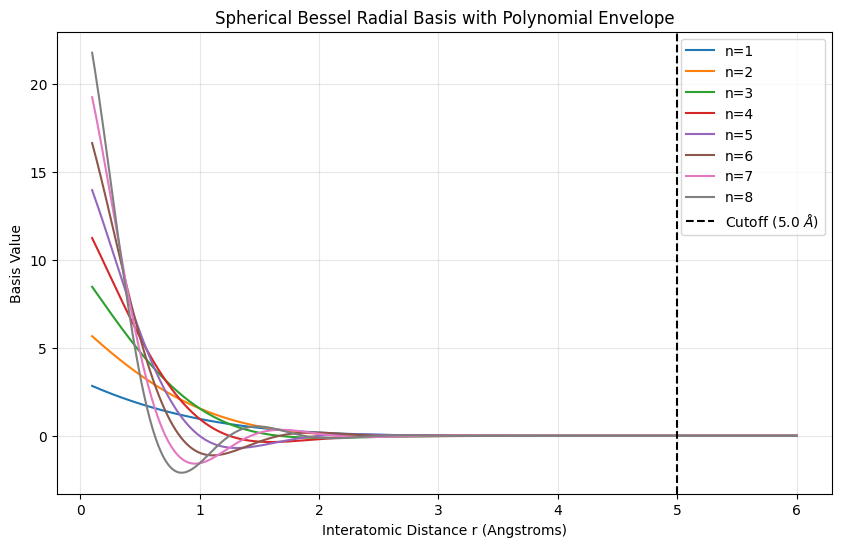

In [2]:
r_max = 5.0
num_radial = 8
radial_basis = BesselBasis(cutoff=r_max, num_radial=num_radial)

# Create an array of distances from 0 to 6 Angstroms
distances = torch.linspace(0.1, 6.0, 500)
embeddings = radial_basis(distances).detach().numpy()

plt.figure(figsize=(10, 6))
for i in range(num_radial):
    plt.plot(distances.numpy(), embeddings[:, i], label=f'n={i+1}')
    
plt.axvline(x=r_max, color='k', linestyle='--', label=f'Cutoff ({r_max} $\AA$)')
plt.title("Spherical Bessel Radial Basis with Polynomial Envelope")
plt.xlabel("Interatomic Distance r (Angstroms)")
plt.ylabel("Basis Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Notice how all the basis functions smoothly decay to exactly zero at 5.0 $\AA$.

### The Angular Basis (Spherical Harmonics)

The angular basis embeds the *direction* vector between two atoms into equivariant features. We use `e3nn`'s implementation of real spherical harmonics.

In [3]:
l_max = 2
sh_basis = SphericalHarmonicsBasis(l_max=l_max)

print(f"Irreps out for l_max={l_max}: {sh_basis.irreps_out}")

# Let's embed a single unit vector pointing strictly in the Z direction
z_vector = torch.tensor([[0.0, 0.0, 1.0]])
sh_feat = sh_basis(z_vector)

print("\nSpherical Harmonics feature vector for [0, 0, 1]:")
print(sh_feat)

expected_dim = sum([(2*l + 1) for l in range(l_max + 1)])
print(f"\nExpected Dimension (sum of 2l+1): {expected_dim}")
print(f"Actual Dimension: {sh_feat.shape[1]}")

Irreps out for l_max=2: 1x0e+1x1o+1x2e

Spherical Harmonics feature vector for [0, 0, 1]:
tensor([[ 1.0000,  0.0000,  0.0000,  1.7321,  0.0000,  0.0000, -1.1180,  0.0000,
          1.9365]])

Expected Dimension (sum of 2l+1): 9
Actual Dimension: 9
